In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load data
df_q2 = pd.read_csv('q2_customers.csv')

# 2. Scaling (Essential because K-Means uses distances)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_q2)

print("Data loaded and scaled. Ready for clustering.")

Data loaded and scaled. Ready for clustering.


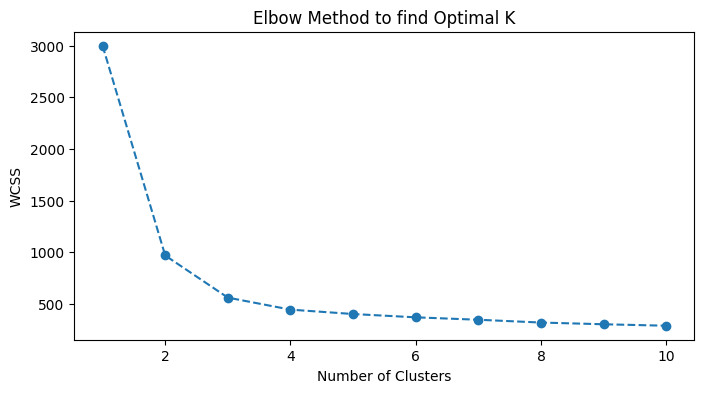

In [2]:
# Calculate WCSS for different numbers of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the graph
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to find Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

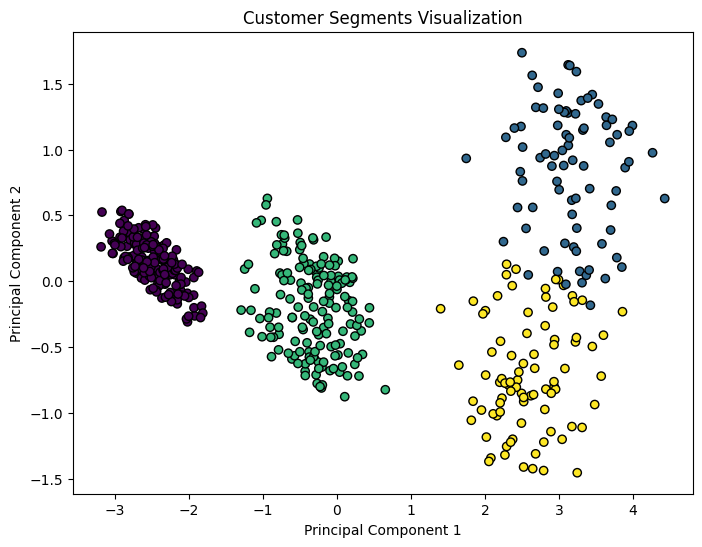

Cluster Centroids (Business Profiles):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


In [3]:
# We will use K=4 based on the elbow point
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_q2['cluster'] = kmeans.fit_predict(scaled_data)

# PCA to turn many columns into 2 columns for a 2D plot
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df_q2['cluster'], cmap='viridis', edgecolors='k')
plt.title('Customer Segments Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Print centroids (The "average" person in each group)
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df_q2.columns[:-1])
print("Cluster Centroids (Business Profiles):")
centroids